# Pacotes

In [33]:
import os
import sys
import yaml
import pandas as pd
import seaborn as sns
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.insert(0, project_root)

from functions.feature_selection import FeatureSelectionOrchestrator
from utils.plots import Pearson_correlation, Bar_plot, plot_numerical_data
from Regression.house_prices.src.features.feat_eng_pipeline import PreprocessingOrchestrator
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [34]:
import warnings
warnings.filterwarnings('ignore')

# Config

In [35]:
with open(os.path.join("../config/config.yaml"), "r") as f:
    config = yaml.safe_load(f)
        
with open(os.path.join( "../config/pipeline.yaml"), "r") as f:
    config_pipe = yaml.safe_load(f)  

# Load dataset

In [36]:
X_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['processed'],
            "train_features.parquet")
    )
y_train = X_train[config_pipe['features']['pipeline1']['target'][0]]

# Features analysis

## Apply Pipeline

In [37]:
preprocessor = PreprocessingOrchestrator(
    numerical_con_1=config_pipe['features']['pipeline1']['num_con_1'],
    numerical_con_2=config_pipe['features']['pipeline1']['num_con_2'],
    numerical_dis=config_pipe['features']['pipeline1']['num_dis_1'],
    categorical_var=config_pipe['features']['pipeline1']['cat_var']
    )
pipe = preprocessor.apply("pipeline1")    
X_train_trans = pipe.fit_transform(X_train)

In [38]:
X_train_trans

,num_con_1_pipe__LotArea,num_con_1_pipe__TotalBsmtSF,num_con_1_pipe__GrLivArea,num_con_2_pipe__MasVnrArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_con_2_pipe__BsmtUnfSF,...,categorical_pipe__BsmtCond_TA,categorical_pipe__BsmtExposure_No,categorical_pipe__BsmtExposure_Rare,categorical_pipe__KitchenQual_Gd,categorical_pipe__KitchenQual_TA,categorical_pipe__GarageFinish_RFn,categorical_pipe__GarageFinish_Unf,categorical_pipe__GarageFinish_Fin,categorical_pipe__SaleType_WD,categorical_pipe__SaleCondition_Normal
0,9.041922,6.753438,7.444249,7,7,8,0,6,8,6,...,1,1,0,1,0,1,0,0,1,1
1,9.169518,7.141245,7.140453,0,7,0,8,0,8,7,...,1,0,1,0,1,1,0,0,1,1
2,9.328123,6.825460,7.487734,6,7,8,0,5,8,7,...,1,0,1,1,0,1,0,0,1,1
3,9.164296,6.629363,7.448334,0,6,8,0,5,8,8,...,0,1,0,1,0,0,1,0,1,0
4,9.565214,7.044033,7.695303,7,7,9,7,7,9,7,...,1,0,0,1,0,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,8.976768,6.860664,7.406711,0,0,8,0,5,8,8,...,1,1,0,0,1,1,0,0,1,1
1456,9.486076,7.341484,7.636752,6,7,0,8,0,8,8,...,1,1,0,0,1,0,1,0,1,1
1457,9.109636,7.050123,7.757906,0,6,9,0,6,7,8,...,0,1,0,1,0,1,0,0,1,1
1458,9.181632,6.983790,6.982863,0,4,0,8,0,7,0,...,1,0,1,1,0,0,1,0,1,1


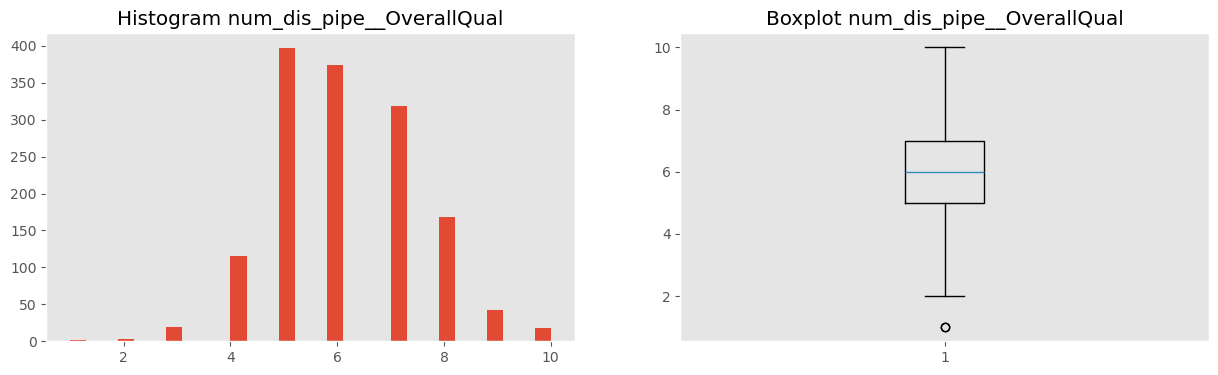

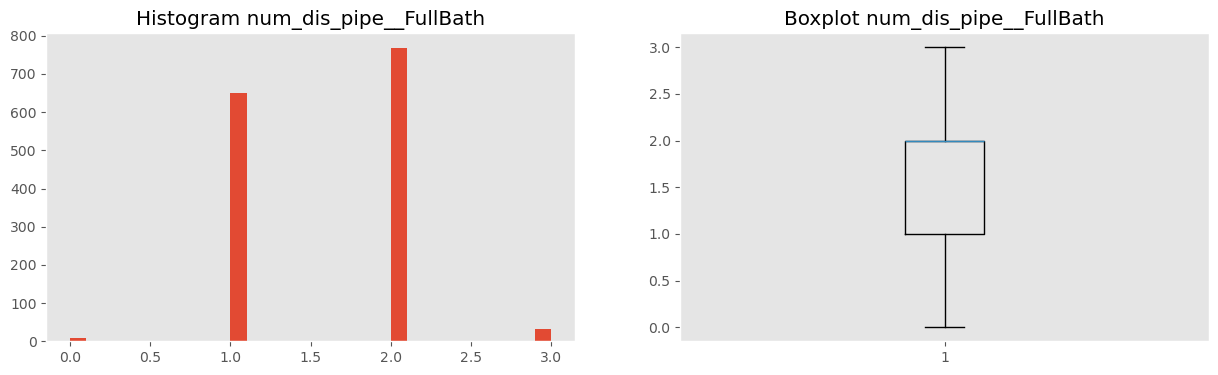

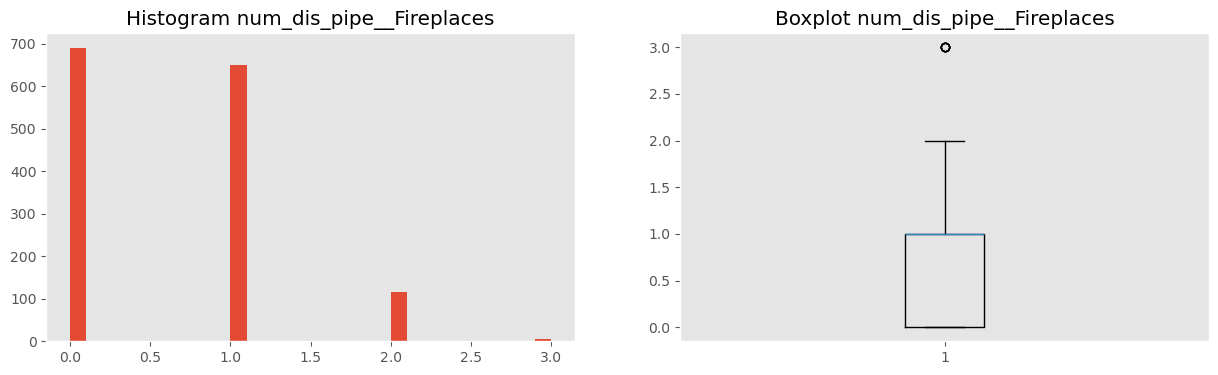

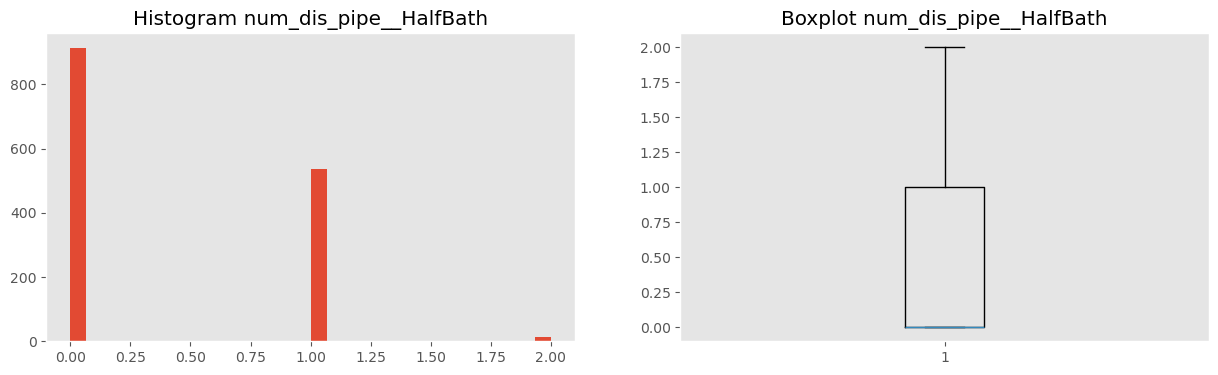

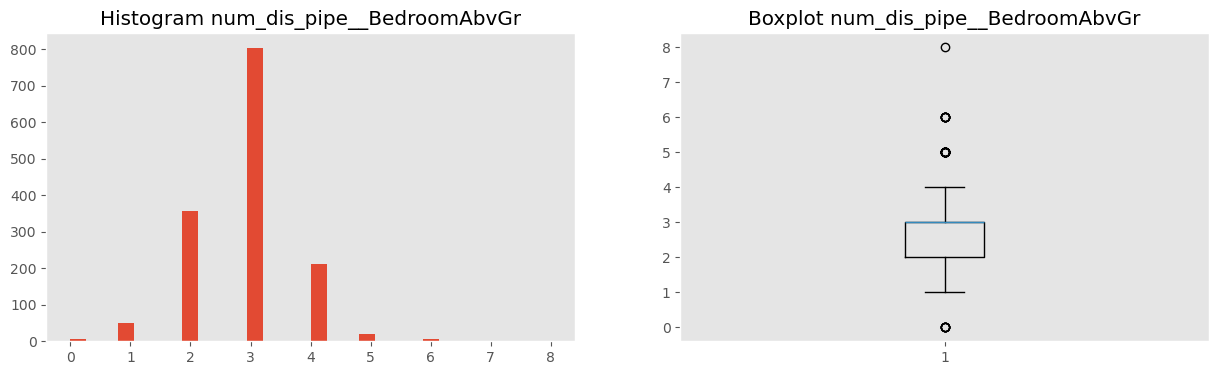

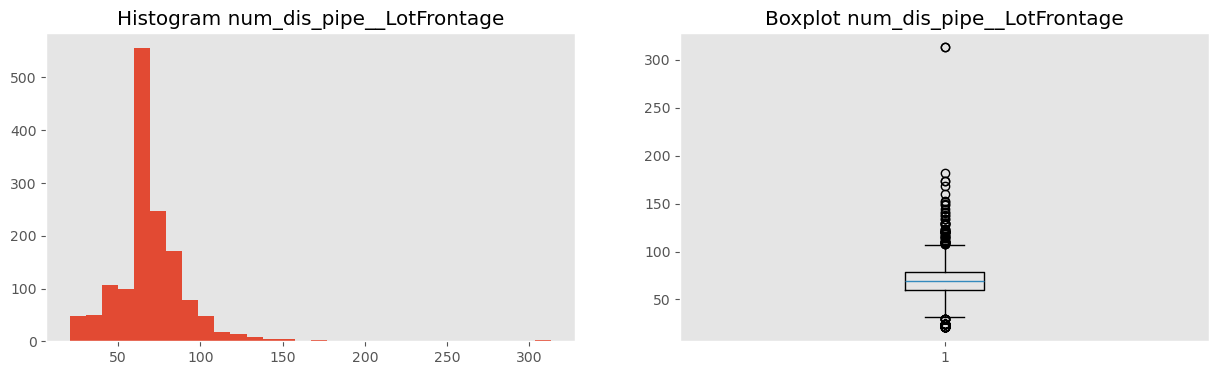

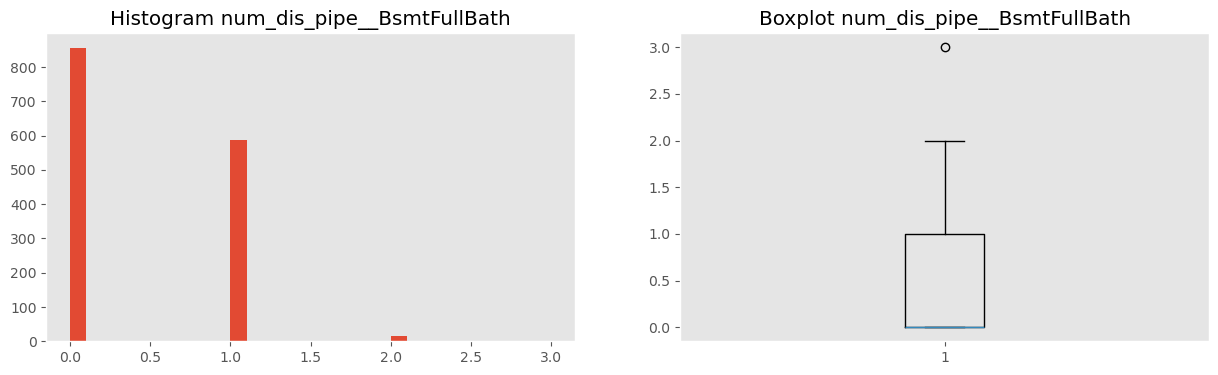

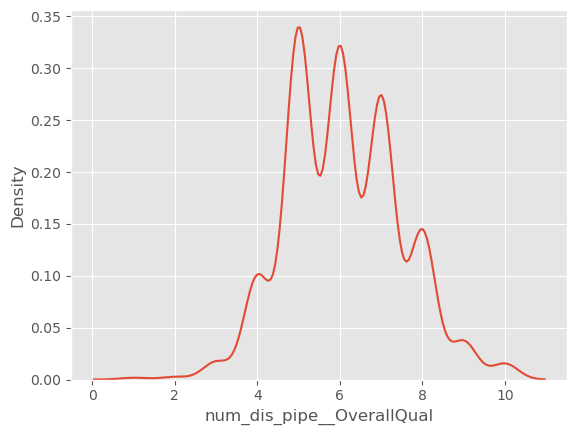

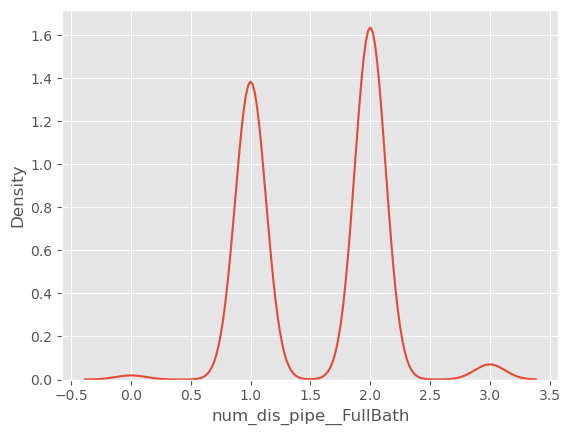

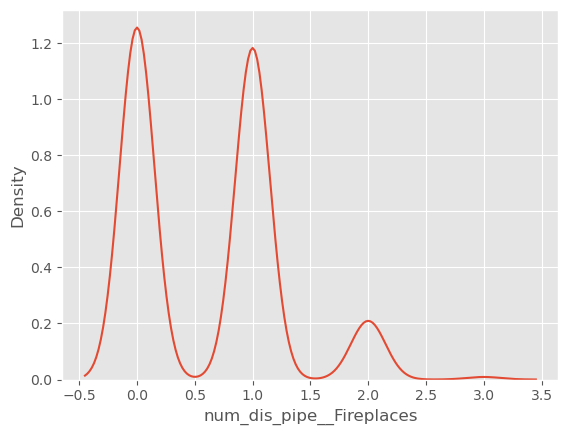

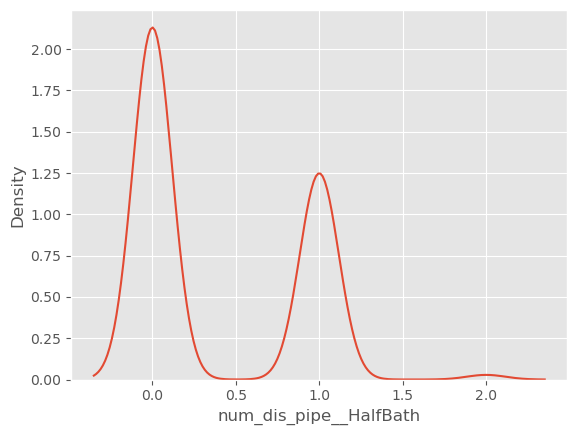

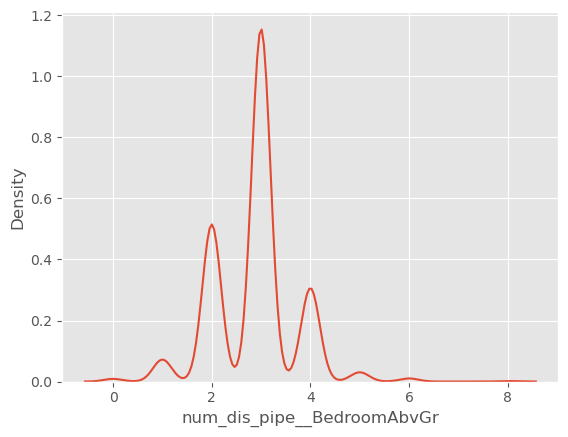

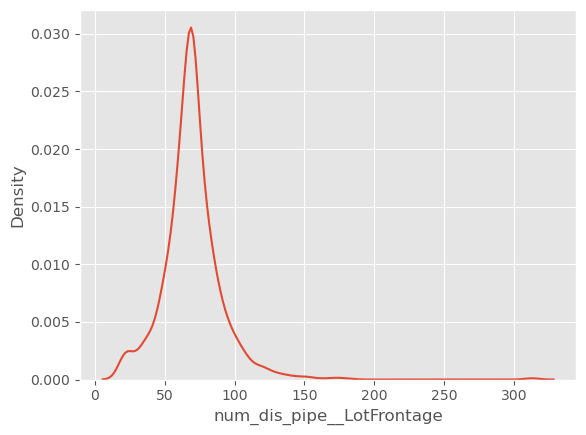

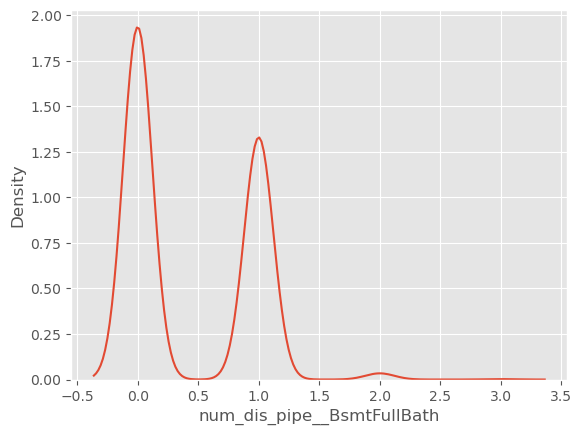

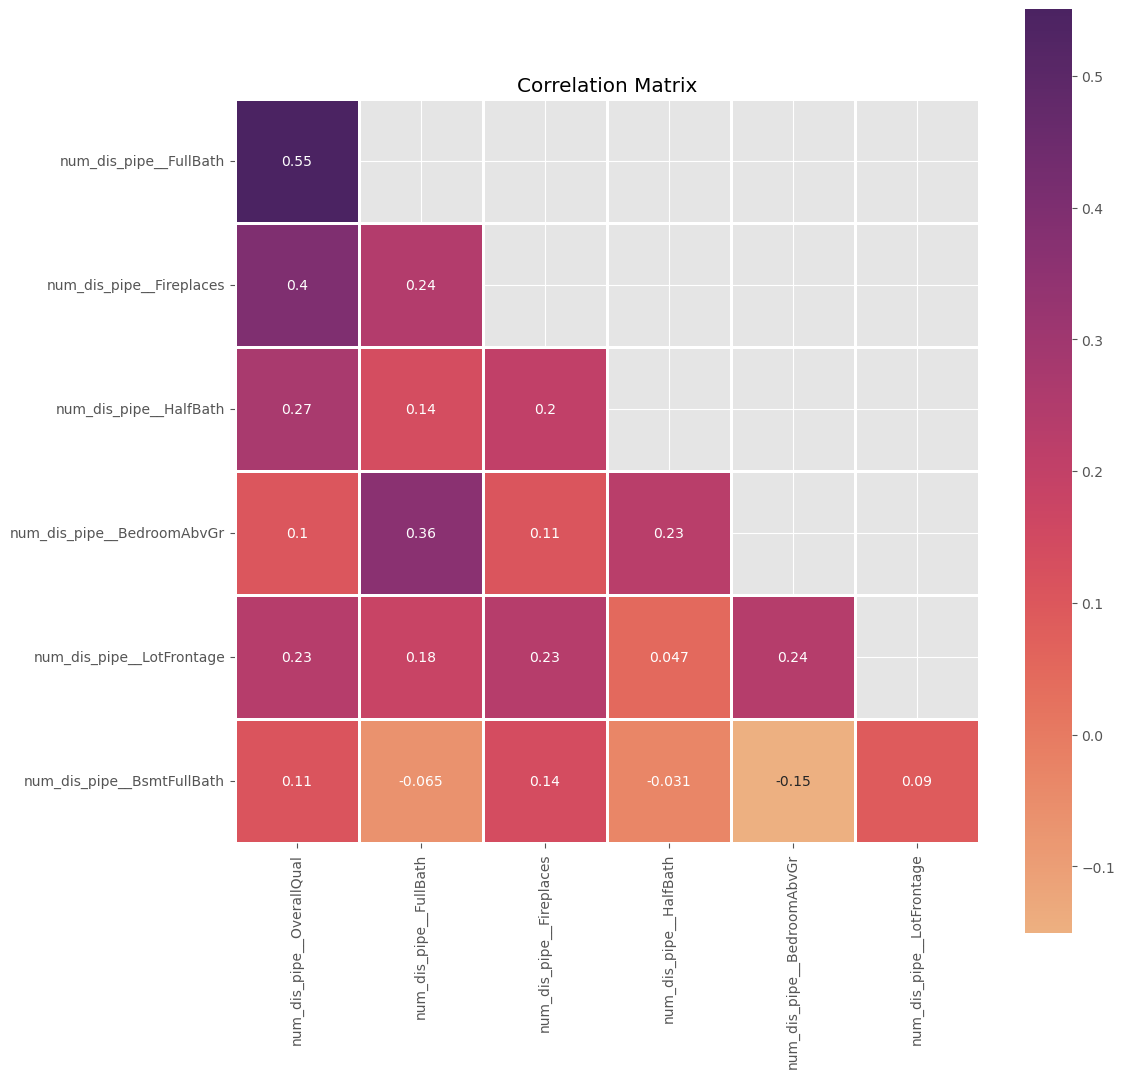

In [39]:
plot_numerical_data(X_train_trans.filter(regex='num_dis_pipe'), target=None)

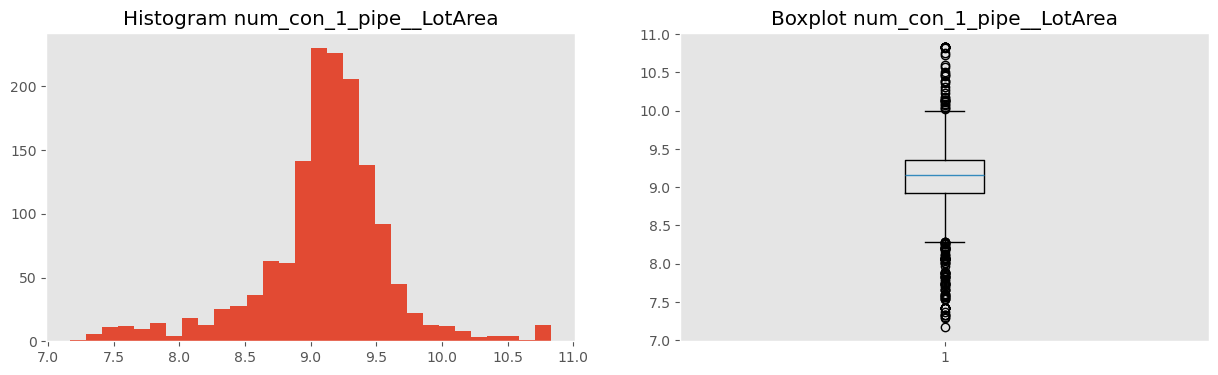

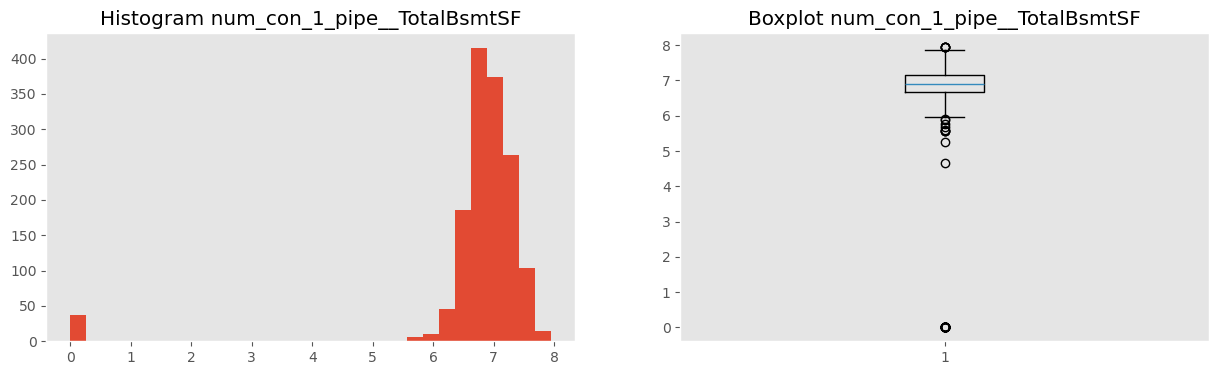

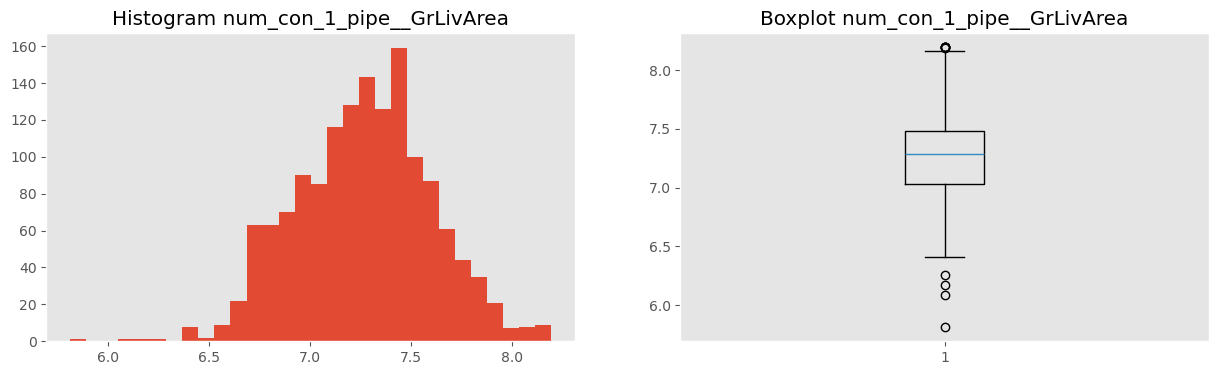

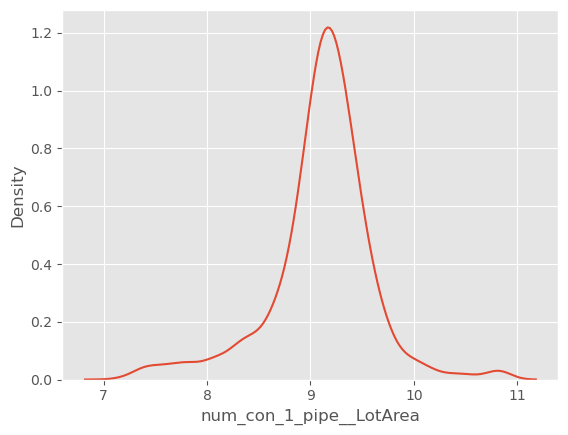

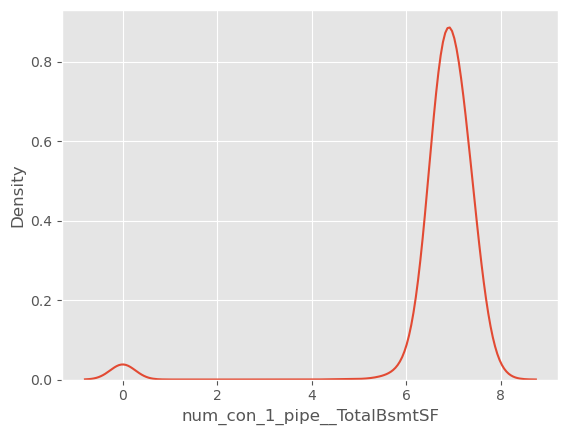

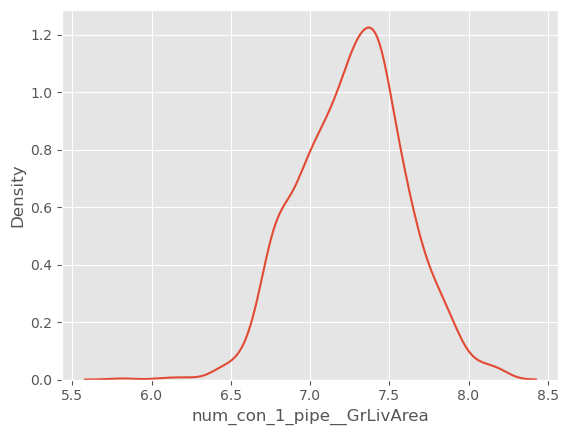

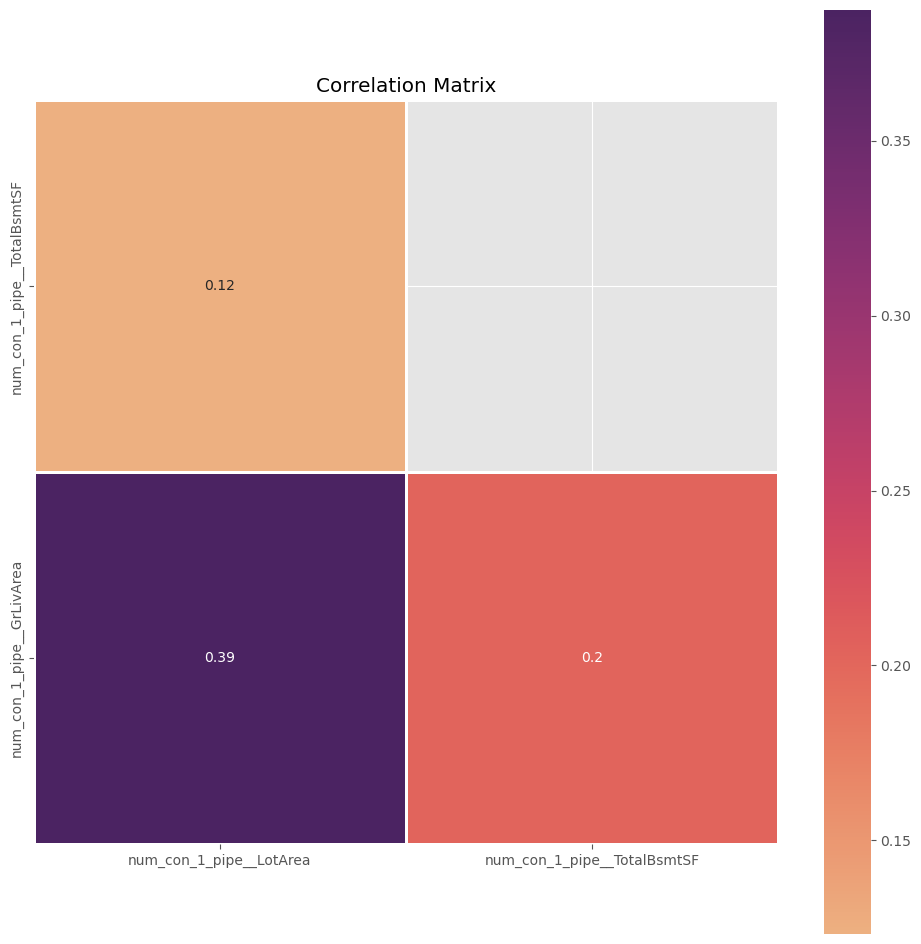

In [40]:
plot_numerical_data(X_train_trans.filter(regex='num_con_1_pipe'), target=None)

In [41]:
# for col in X_train_trans.filter(like='categorical').columns:
#     Bar_plot(X_train_trans[col].value_counts(), title=col)

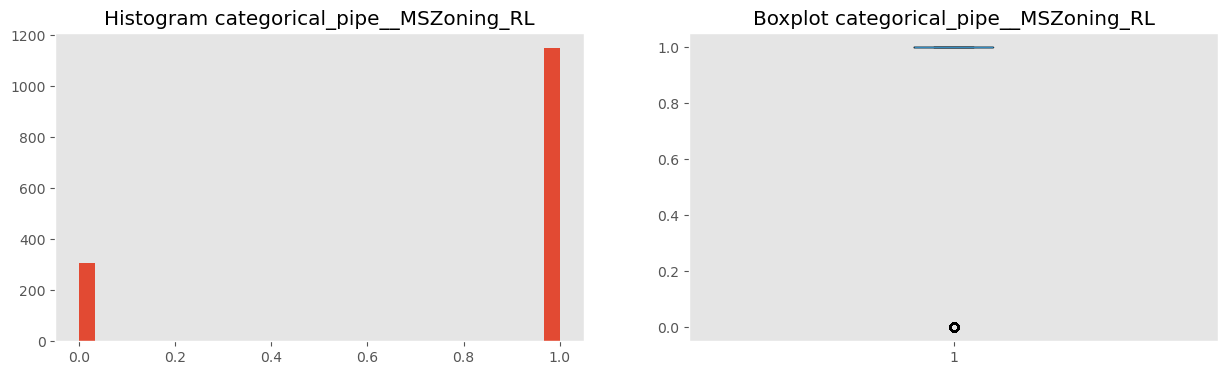

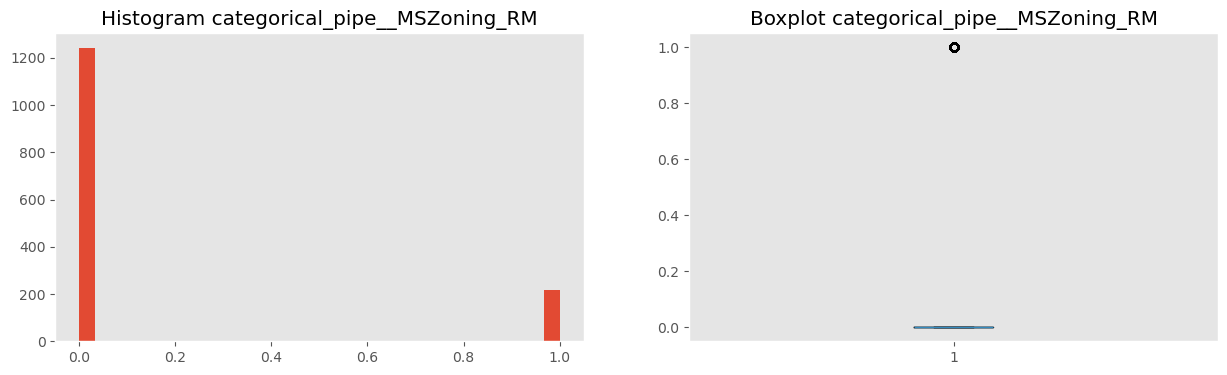

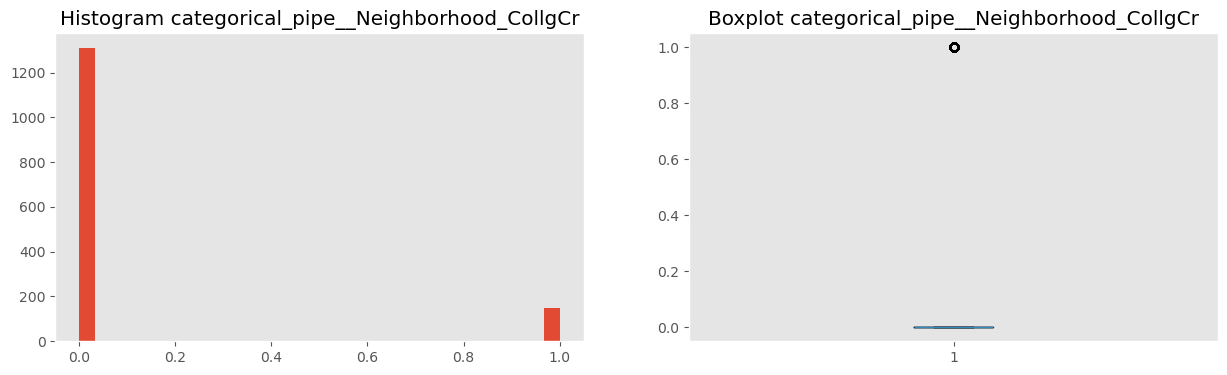

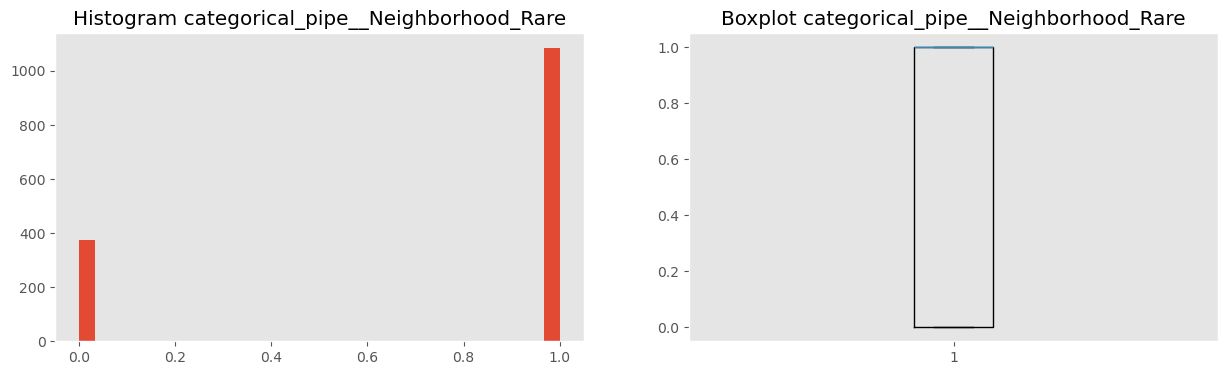

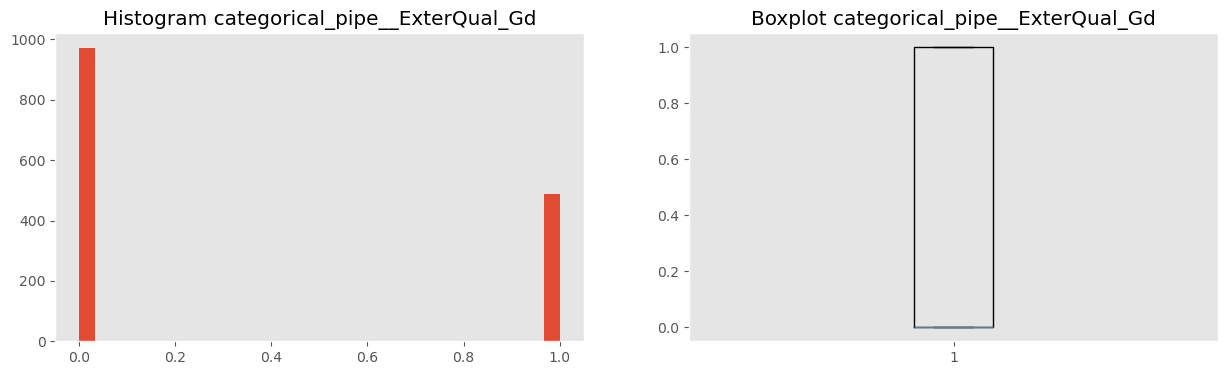

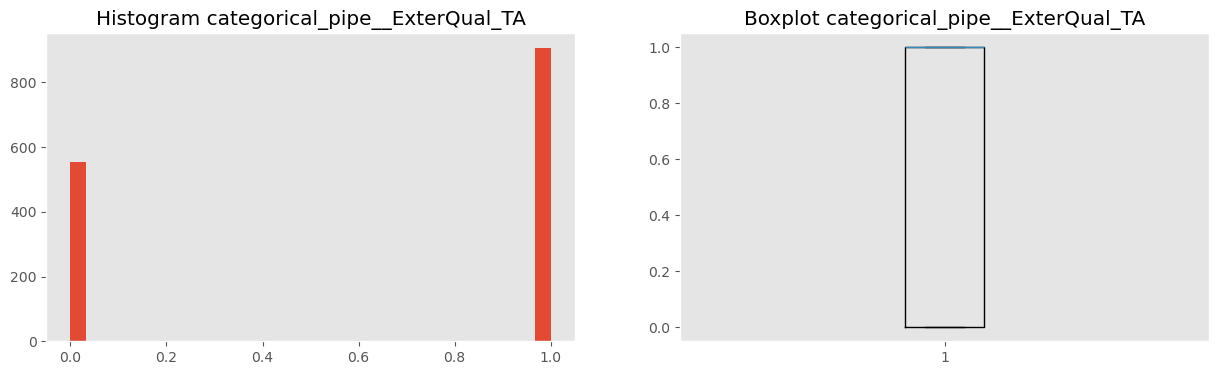

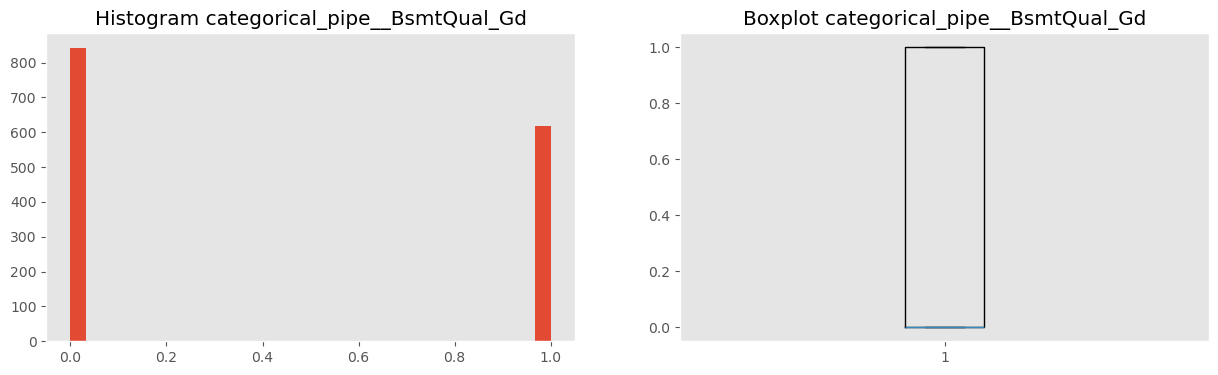

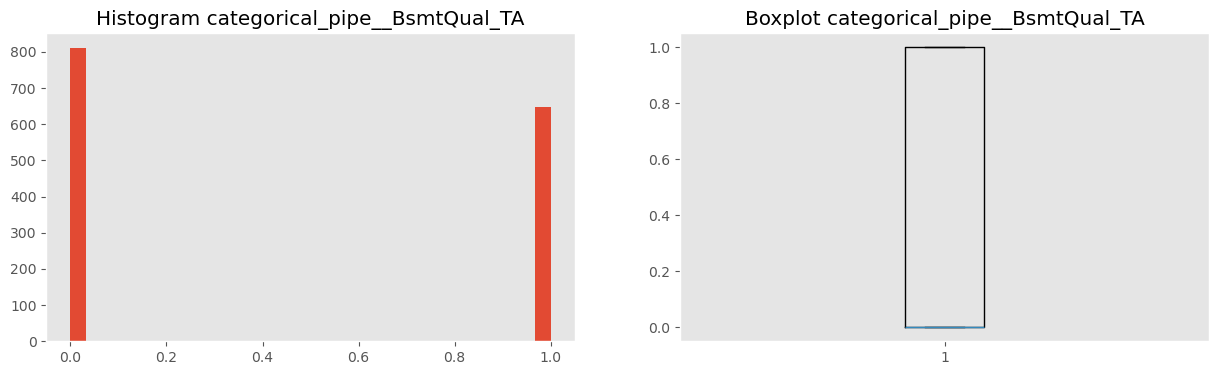

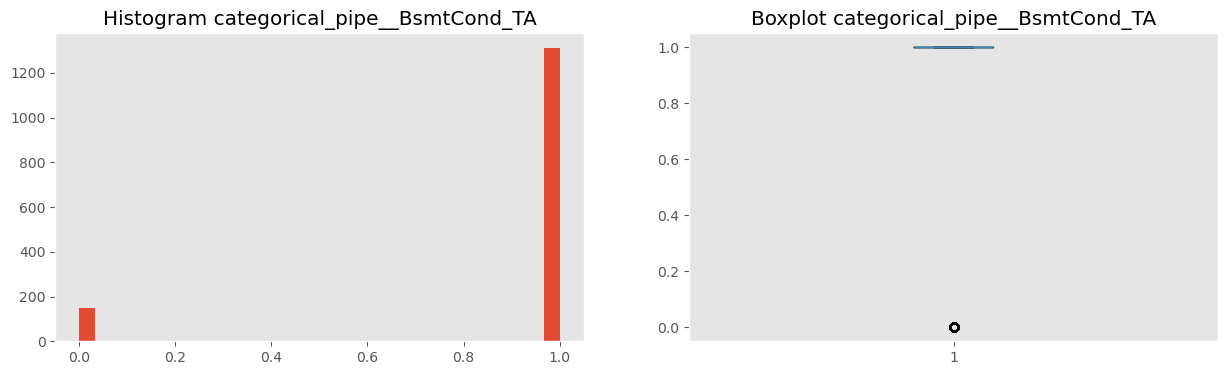

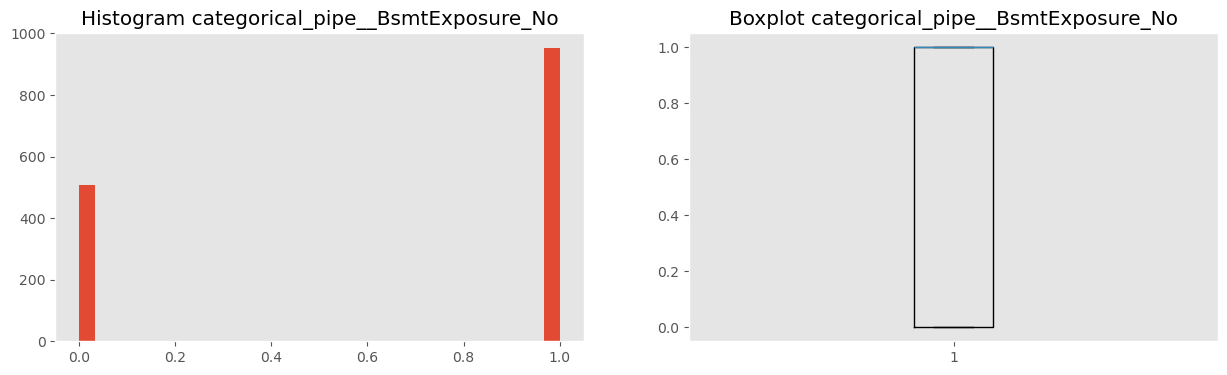

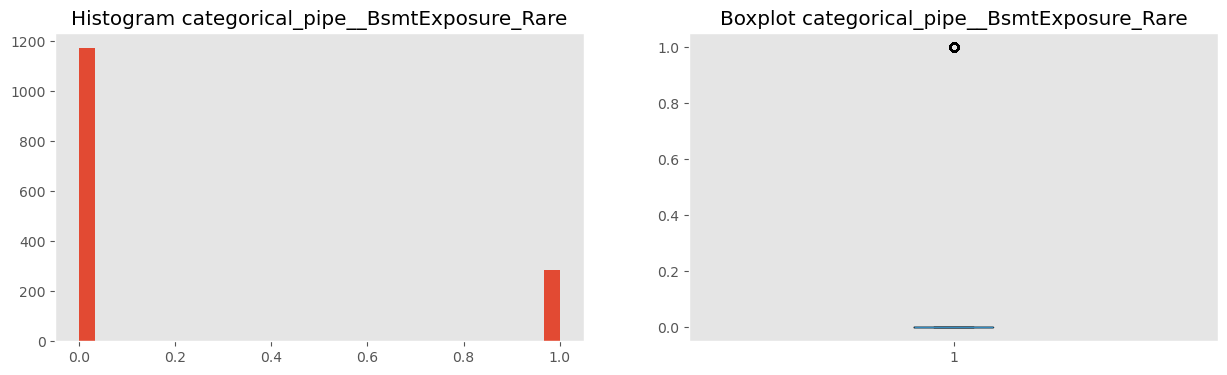

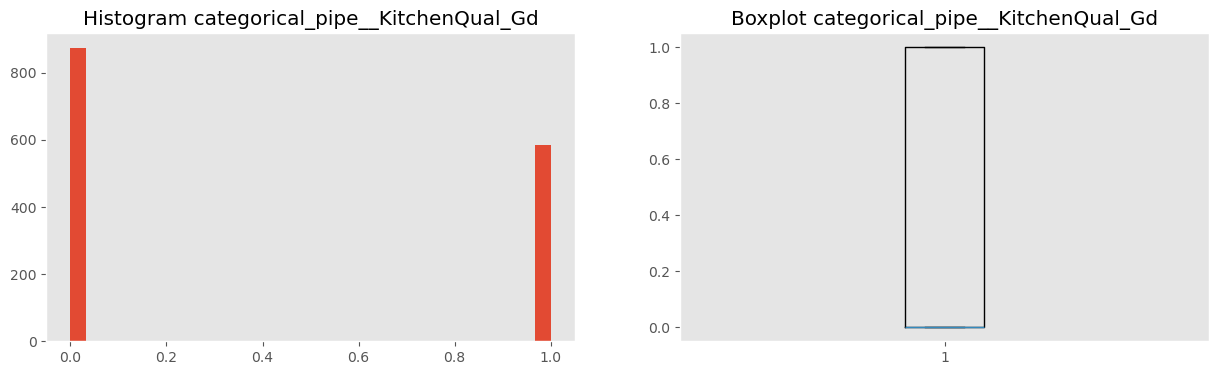

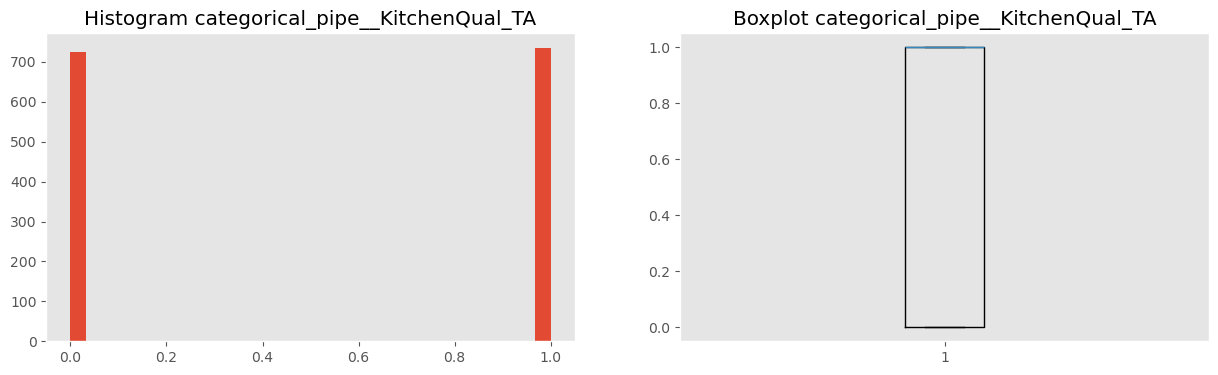

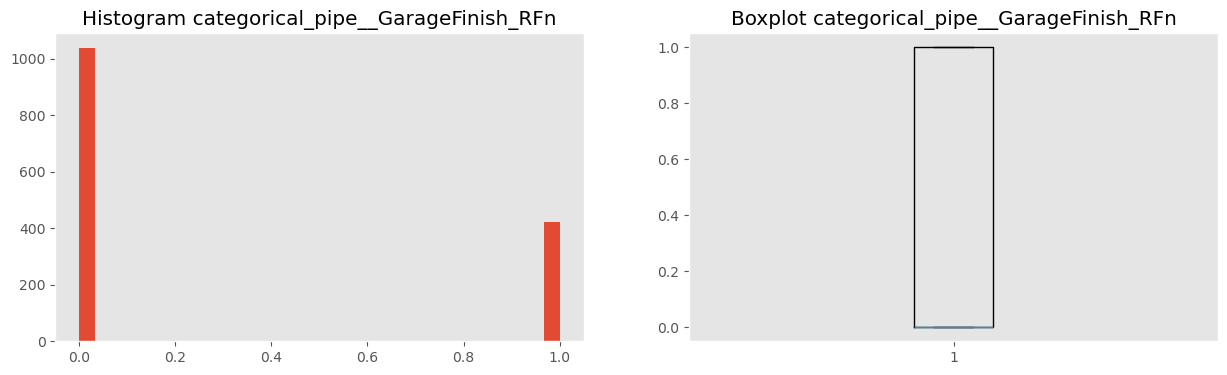

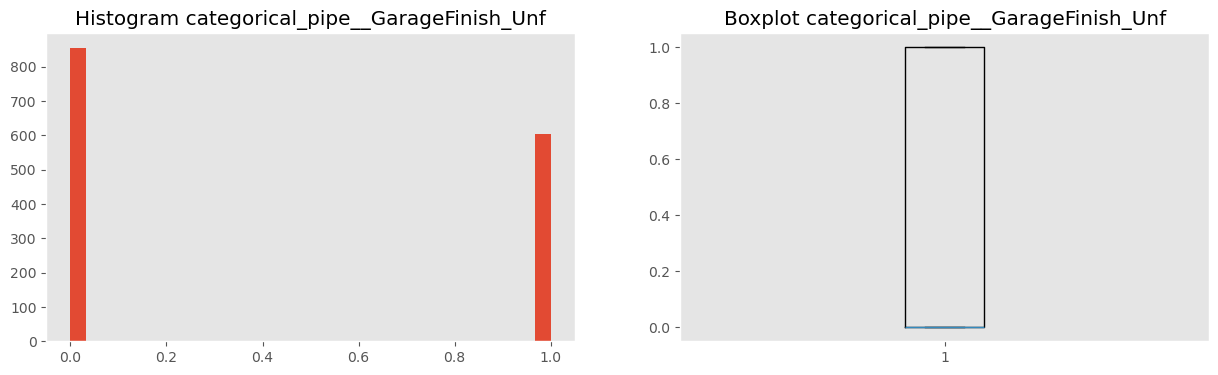

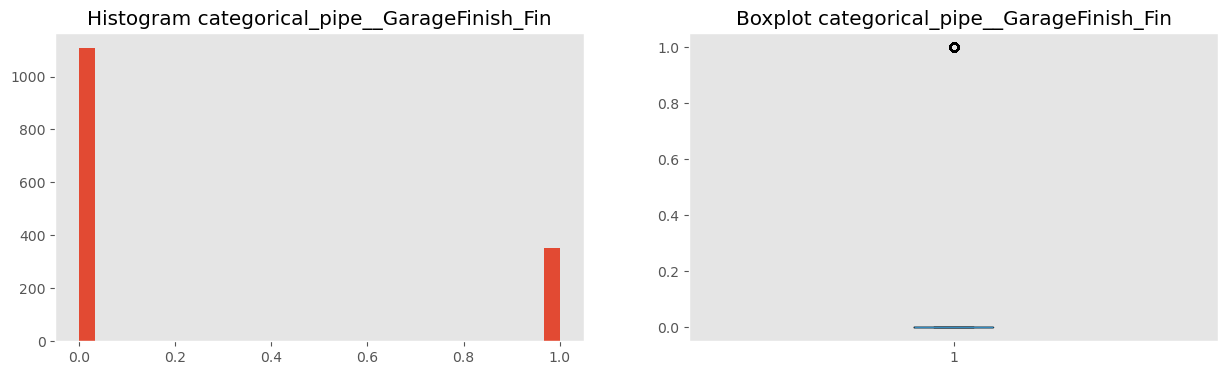

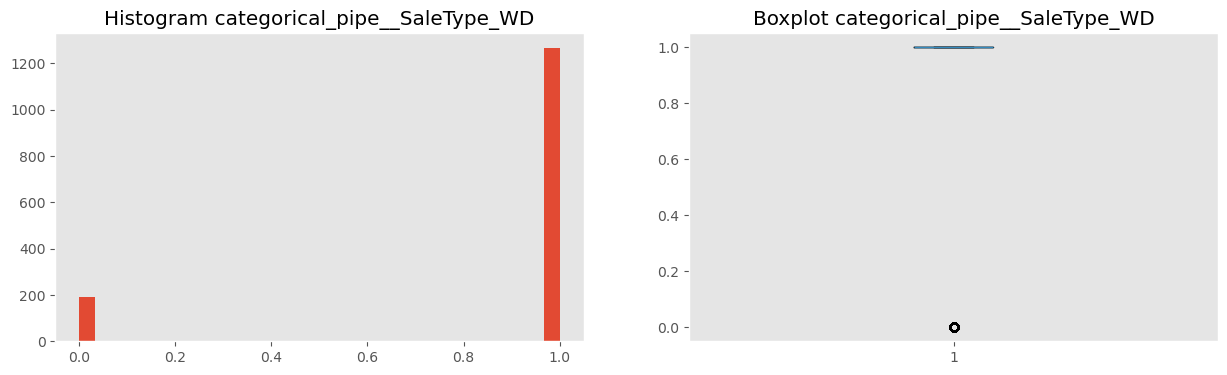

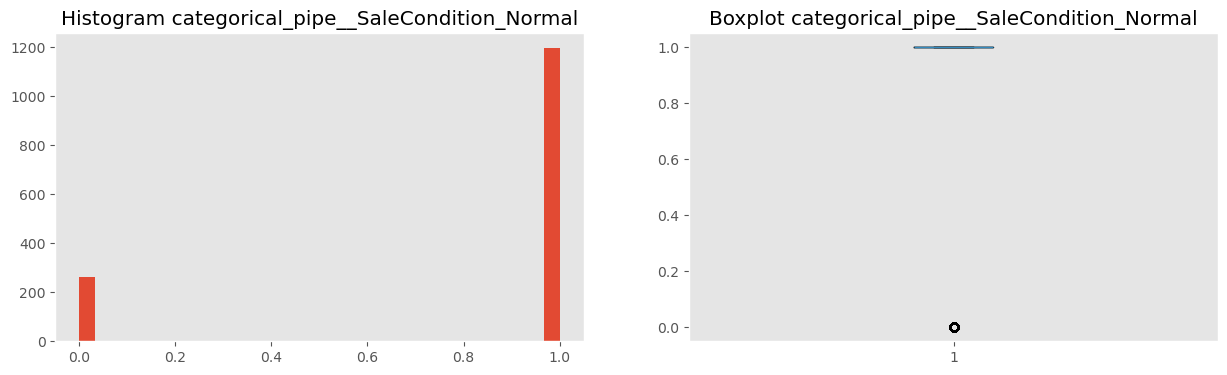

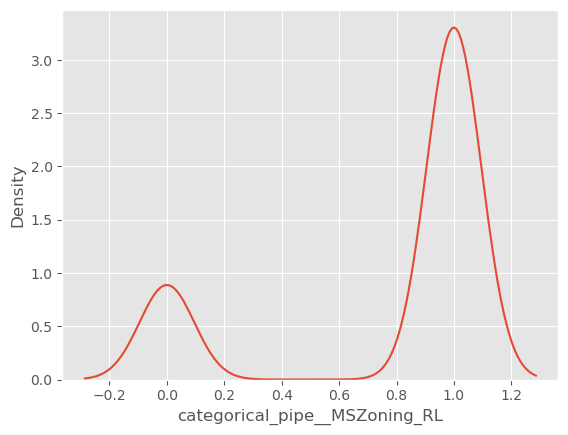

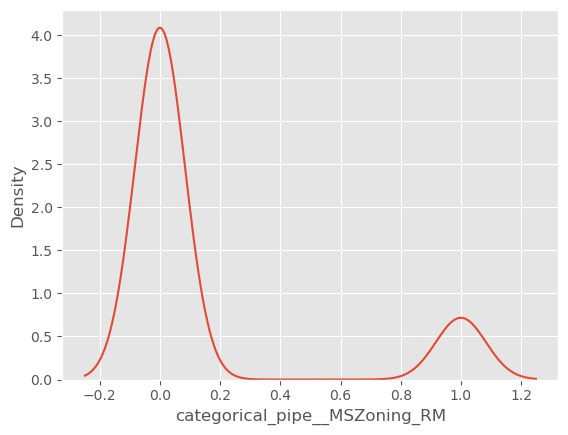

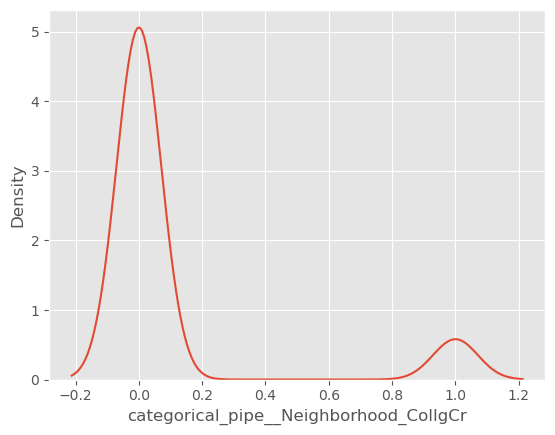

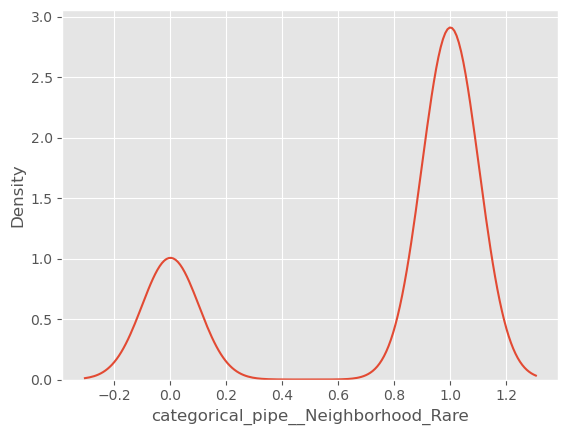

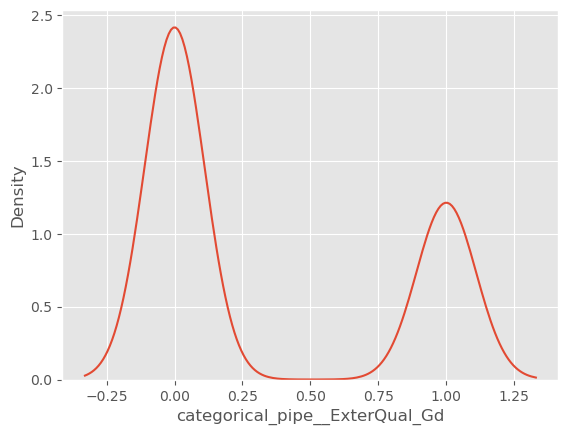

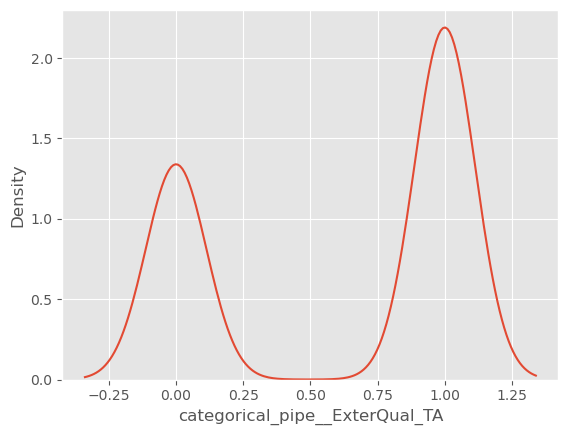

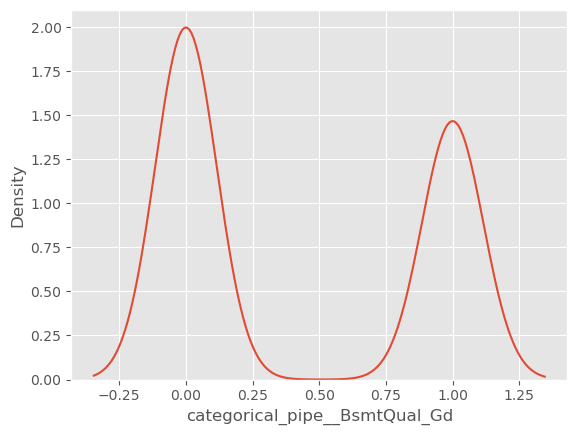

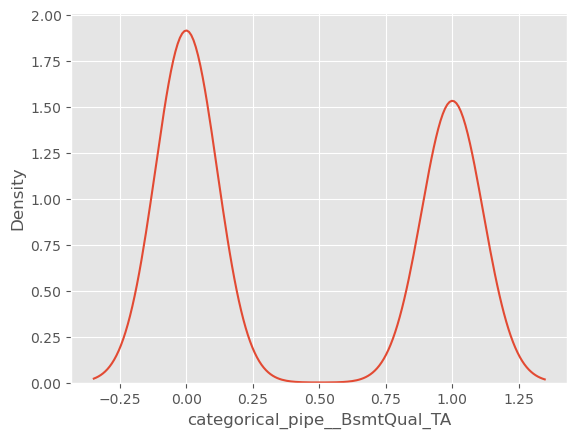

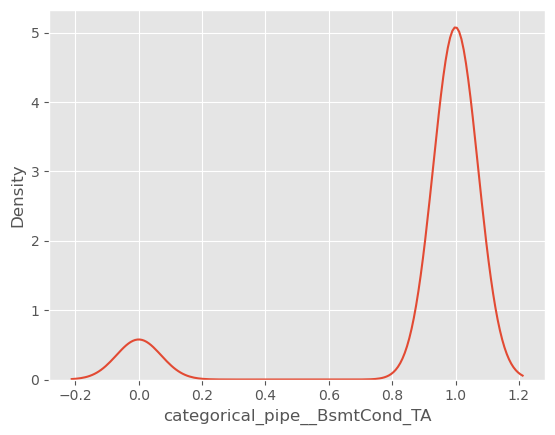

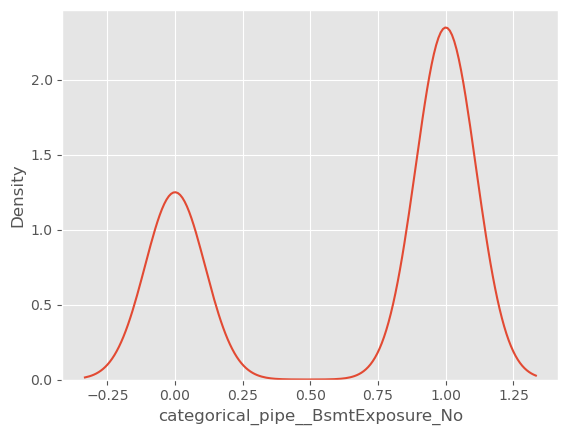

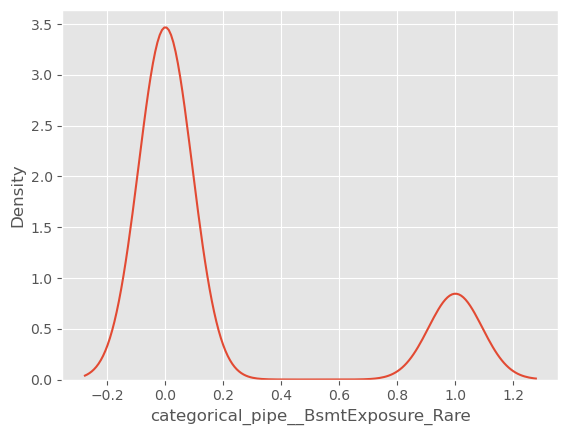

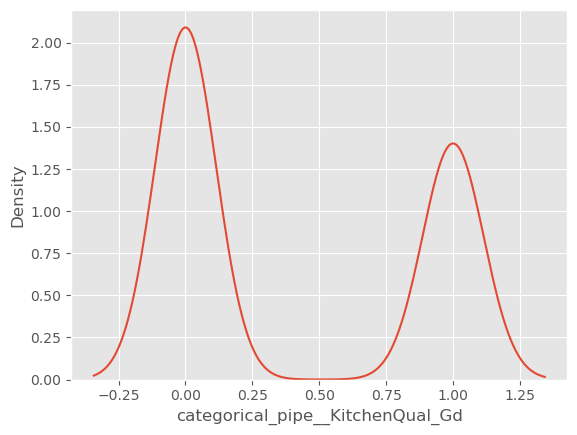

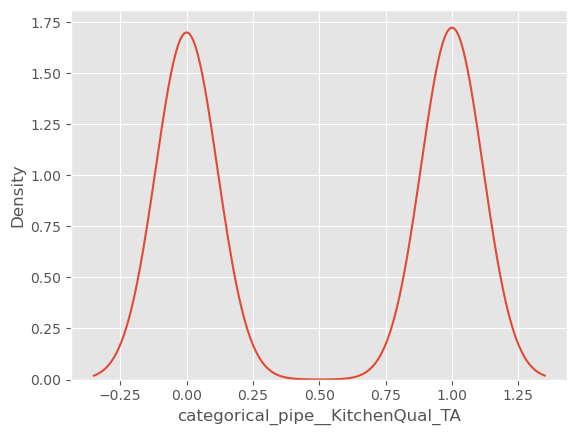

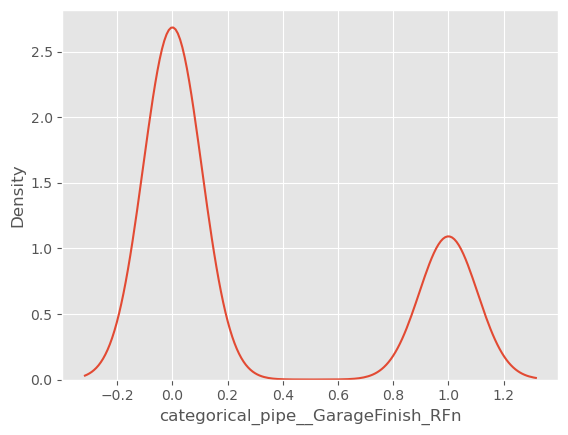

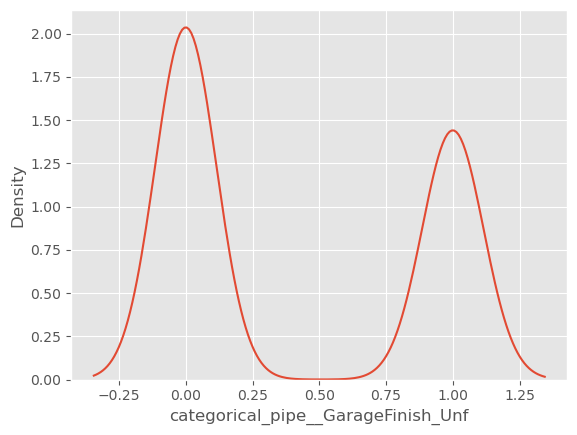

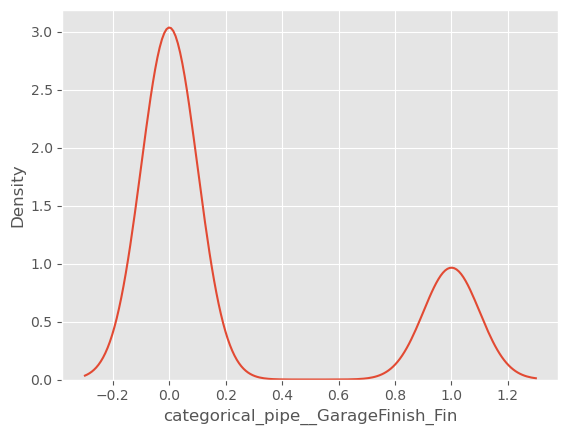

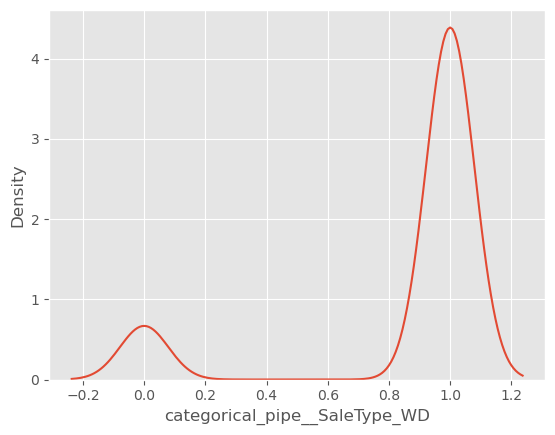

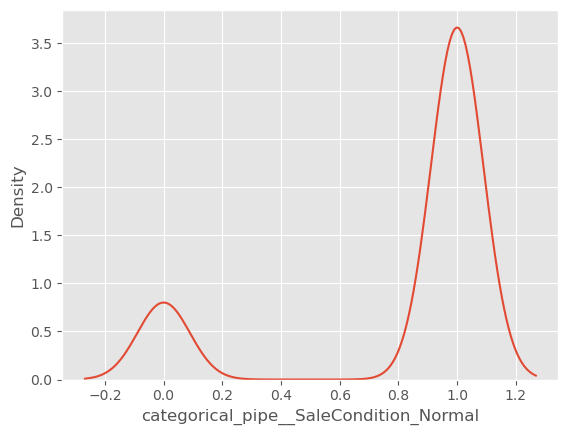

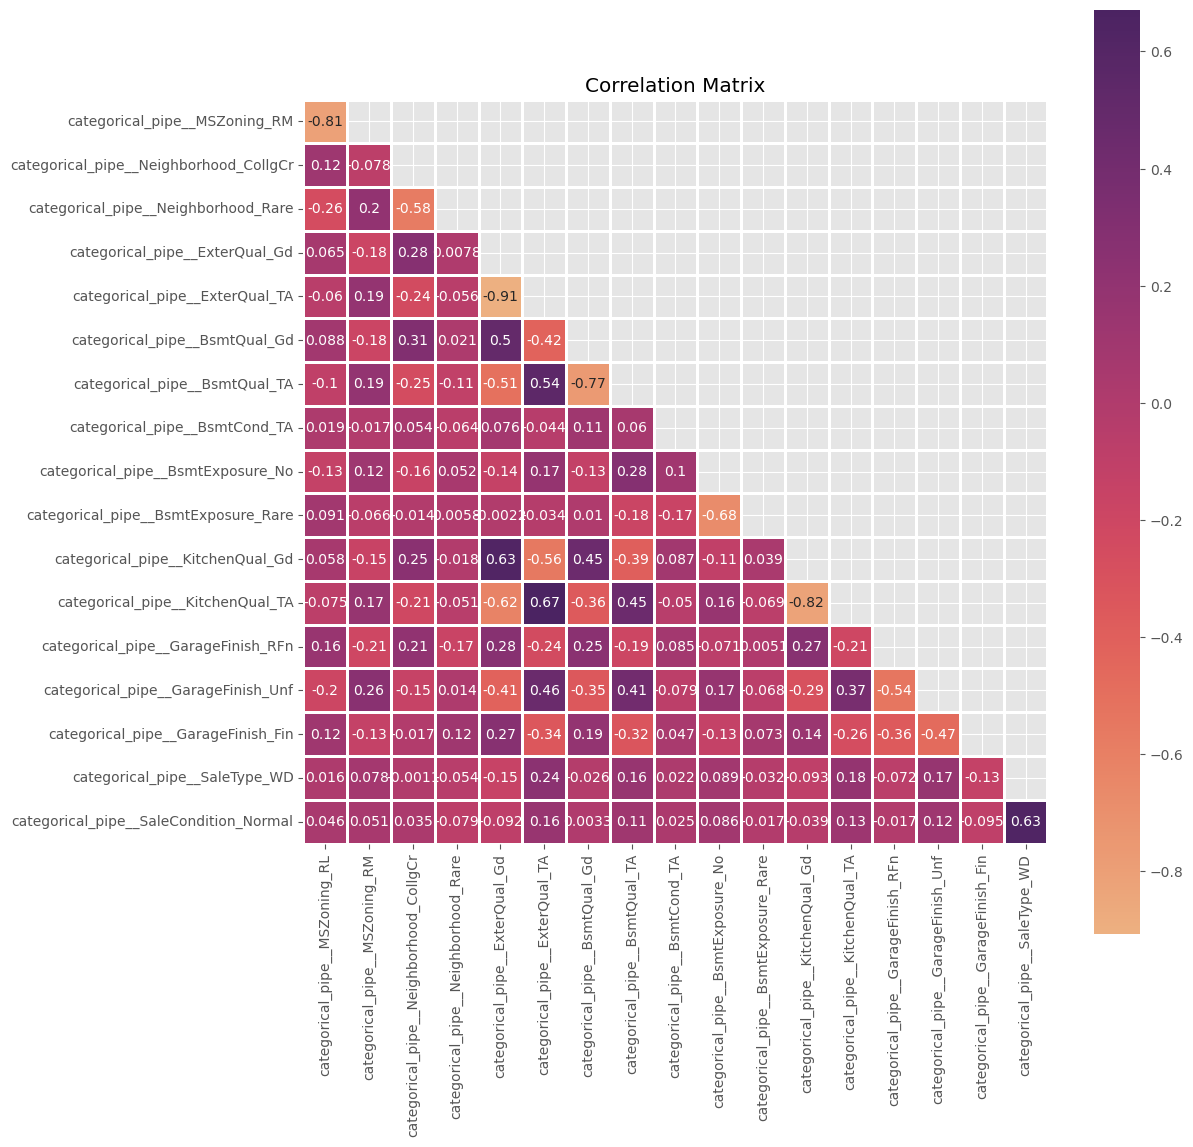

In [42]:
plot_numerical_data(X_train_trans.filter(regex='categorical'), target=None)

# Univariate Feat Selection

## Orquestrador

In [51]:
X_train_trans.filter(like='num')

,num_con_1_pipe__LotArea,num_con_1_pipe__TotalBsmtSF,num_con_1_pipe__GrLivArea,num_con_2_pipe__MasVnrArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_con_2_pipe__BsmtUnfSF,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,num_dis_pipe__Fireplaces,num_dis_pipe__HalfBath,num_dis_pipe__BedroomAbvGr,num_dis_pipe__LotFrontage,num_dis_pipe__BsmtFullBath
0,9.041922,6.753438,7.444249,7,7,8,0,6,8,6,7,2,0,1,3,65.0,1
1,9.169518,7.141245,7.140453,0,7,0,8,0,8,7,6,2,1,0,3,80.0,0
2,9.328123,6.825460,7.487734,6,7,8,0,5,8,7,7,2,1,1,3,68.0,1
3,9.164296,6.629363,7.448334,0,6,8,0,5,8,8,7,1,1,0,3,60.0,1
4,9.565214,7.044033,7.695303,7,7,9,7,7,9,7,8,2,1,1,4,84.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,8.976768,6.860664,7.406711,0,0,8,0,5,8,8,6,2,1,1,3,62.0,0
1456,9.486076,7.341484,7.636752,6,7,0,8,0,8,8,6,2,2,0,3,85.0,1
1457,9.109636,7.050123,7.757906,0,6,9,0,6,7,8,7,2,2,0,4,66.0,0
1458,9.181632,6.983790,6.982863,0,4,0,8,0,7,0,5,1,0,0,2,68.0,1


In [43]:
feature_selection = FeatureSelectionOrchestrator()

## Constant Features

In [ ]:
constant_features = feature_selection.apply(
        "DropConstantFeatures", 
        X_train_trans, 
        y_train,
        threshold=0.90)

constant_features

## Duplicate Features

In [ ]:
duplicate_features = feature_selection.apply(
        "DropDuplicateFeatures", 
        X_train_trans,        
        y_train
        )

duplicate_features

In [ ]:
# QuiSquare = feature_selection.apply(
#         "QuiSquare", 
#         X_train_trans.filter(like='categorical'), 
#         y_train)

# [i
#     for i in QuiSquare.loc[QuiSquare < 0.05].index
# ]

# # feature selection based on QuiSquare test
# [i
#     for i in QuiSquare.loc[QuiSquare > 0.05].index
# ]

## Anova

In [52]:
Anova = feature_selection.apply(
        "Anova",
        X_train_trans.filter(like='num'),
        y_train.values)

In [71]:
Anova.loc[Anova > 0.05]

num_con_2_pipe__BsmtUnfSF    0.9189
Name: Anova, dtype: float64

In [72]:
Anova.loc[Anova < 0.05]

num_dis_pipe__OverallQual      1.344399e-114
num_con_1_pipe__GrLivArea       5.097526e-59
num_dis_pipe__FullBath          5.306331e-40
num_con_1_pipe__TotalBsmtSF     5.135714e-27
num_dis_pipe__Fireplaces        1.236756e-11
num_con_2_pipe__OpenPorchSF     1.985910e-11
num_con_2_pipe__GarageArea      7.588050e-09
num_con_2_pipe__MasVnrArea      4.170467e-07
num_dis_pipe__HalfBath          1.410758e-06
num_con_2_pipe__BsmtFinSF1      4.023059e-05
num_con_1_pipe__LotArea         8.820255e-05
num_con_2_pipe__WoodDeckSF      9.908564e-05
num_dis_pipe__BedroomAbvGr      2.144007e-03
num_dis_pipe__LotFrontage       5.131766e-03
num_con_2_pipe__2ndFlrSF        1.860987e-02
num_dis_pipe__BsmtFullBath      4.326529e-02
Name: Anova, dtype: float64

## Mutual Info

In [73]:
mi = feature_selection.apply(
        "MutualInformationReg", 
        X_train_trans, 
        y_train)

In [74]:
mi

num_dis_pipe__OverallQual                 0.557306
num_con_1_pipe__GrLivArea                 0.490370
num_con_1_pipe__TotalBsmtSF               0.337155
num_con_2_pipe__GarageArea                0.282456
categorical_pipe__ExterQual_TA            0.275935
num_dis_pipe__FullBath                    0.243086
categorical_pipe__KitchenQual_TA          0.222316
categorical_pipe__ExterQual_Gd            0.220349
num_dis_pipe__LotFrontage                 0.217521
num_con_1_pipe__LotArea                   0.182815
categorical_pipe__BsmtQual_TA             0.182671
categorical_pipe__KitchenQual_Gd          0.173662
num_dis_pipe__Fireplaces                  0.168478
num_con_2_pipe__OpenPorchSF               0.154855
categorical_pipe__BsmtQual_Gd             0.153094
num_con_2_pipe__MasVnrArea                0.128732
categorical_pipe__GarageFinish_Unf        0.117655
categorical_pipe__GarageFinish_Fin        0.111042
num_con_2_pipe__BsmtFinSF1                0.110130
num_con_2_pipe__WoodDeckSF     

## Correlation

In [75]:
   
corr = feature_selection.apply(
        "PearsonCorrelation", 
        X_train_trans.filter(like='num'), 
        y_train)

In [76]:
corr

,num_con_1_pipe__LotArea,num_con_1_pipe__TotalBsmtSF,num_con_1_pipe__GrLivArea,num_con_2_pipe__MasVnrArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_con_2_pipe__BsmtUnfSF,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,num_dis_pipe__Fireplaces,num_dis_pipe__HalfBath,num_dis_pipe__BedroomAbvGr,num_dis_pipe__LotFrontage,num_dis_pipe__BsmtFullBath
num_con_1_pipe__LotArea,1.000000,0.123207,0.387456,0.074156,0.096741,-0.014823,0.126062,0.141532,0.214440,0.047012,0.182388,0.179479,0.322062,0.044750,0.287169,0.574057,0.129991
num_con_1_pipe__TotalBsmtSF,0.123207,1.000000,0.203639,0.185357,0.289088,-0.058708,0.151755,0.180113,0.181310,0.515317,0.342823,0.090294,0.177588,0.081361,0.027267,0.124605,0.211834
num_con_1_pipe__GrLivArea,0.387456,0.203639,1.000000,0.303785,-0.012147,0.560277,0.218027,0.393288,0.315085,0.224087,0.612348,0.653745,0.466904,0.430841,0.541452,0.321994,0.017233
num_con_2_pipe__MasVnrArea,0.074156,0.185357,0.303785,1.000000,0.186864,-0.011705,0.164842,0.205187,0.249939,0.089509,0.410652,0.276196,0.224690,0.150823,0.092699,0.145415,0.115089
num_con_2_pipe__BsmtFinSF1,0.096741,0.289088,-0.012147,0.186864,1.000000,-0.206972,0.089192,0.013142,0.116020,-0.279728,0.057804,-0.082270,0.149466,-0.006566,-0.094150,0.081081,0.594347
num_con_2_pipe__2ndFlrSF,-0.014823,-0.058708,0.560277,-0.011705,-0.206972,1.000000,0.038247,0.168917,0.047389,0.088344,0.196317,0.319357,0.131697,0.586497,0.441121,-0.024157,-0.212888
num_con_2_pipe__WoodDeckSF,0.126062,0.151755,0.218027,0.164842,0.089192,0.038247,1.000000,0.131081,0.164214,0.012224,0.279158,0.228179,0.189386,0.110790,0.016865,0.051827,0.165182
num_con_2_pipe__OpenPorchSF,0.141532,0.180113,0.393288,0.205187,0.013142,0.168917,0.131081,1.000000,0.191134,0.182197,0.442274,0.377641,0.202827,0.259301,0.084890,0.136442,0.077678
num_con_2_pipe__GarageArea,0.214440,0.181310,0.315085,0.249939,0.116020,0.047389,0.164214,0.191134,1.000000,0.099319,0.396872,0.241302,0.241712,0.143237,0.023784,0.177985,0.088524
num_con_2_pipe__BsmtUnfSF,0.047012,0.515317,0.224087,0.089509,-0.279728,0.088344,0.012224,0.182197,0.099319,1.000000,0.269992,0.188811,0.103064,0.074400,0.146930,0.097029,-0.267905


## Smart Corr

In [79]:
smart_corr = feature_selection.apply(
        "SmartCorrelatedSelection",
        X_train_trans,
        y_train)

smart_corr

{'corr_feature': ['categorical_pipe__ExterQual_TA',
  'categorical_pipe__ExterQual_Gd'],
 'corr_2_drop': ['categorical_pipe__ExterQual_Gd',
  'categorical_pipe__KitchenQual_Gd',
  'categorical_pipe__MSZoning_RL']}

## MRMR

In [80]:
mrmr = feature_selection.apply(
        "MRMR",        
        X_train_trans,
        y_train,
        method="MIQ"
        )

In [81]:
X_train_trans.shape

(1460, 35)

In [84]:
len(mrmr['features_to_drop'])

28

In [85]:
mrmr['features_to_drop']

['num_con_1_pipe__TotalBsmtSF',
 'num_con_1_pipe__GrLivArea',
 'num_con_2_pipe__MasVnrArea',
 'num_con_2_pipe__BsmtFinSF1',
 'num_con_2_pipe__2ndFlrSF',
 'num_con_2_pipe__WoodDeckSF',
 'num_con_2_pipe__OpenPorchSF',
 'num_con_2_pipe__GarageArea',
 'num_con_2_pipe__BsmtUnfSF',
 'num_dis_pipe__OverallQual',
 'num_dis_pipe__Fireplaces',
 'num_dis_pipe__HalfBath',
 'num_dis_pipe__BedroomAbvGr',
 'num_dis_pipe__LotFrontage',
 'num_dis_pipe__BsmtFullBath',
 'categorical_pipe__MSZoning_RL',
 'categorical_pipe__MSZoning_RM',
 'categorical_pipe__Neighborhood_CollgCr',
 'categorical_pipe__ExterQual_Gd',
 'categorical_pipe__ExterQual_TA',
 'categorical_pipe__BsmtQual_Gd',
 'categorical_pipe__BsmtQual_TA',
 'categorical_pipe__BsmtExposure_Rare',
 'categorical_pipe__KitchenQual_Gd',
 'categorical_pipe__KitchenQual_TA',
 'categorical_pipe__GarageFinish_Unf',
 'categorical_pipe__GarageFinish_Fin',
 'categorical_pipe__SaleCondition_Normal']

In [86]:
mrmr['relevance']

array([0.14318033, 0.22849487, 0.38858249, 0.14669931, 0.28436833,
       0.22807915, 0.17993528, 0.2544774 , 1.58013291, 0.31809357,
       1.12388802, 2.09943816, 0.85319164, 0.45651198, 0.91988343,
       0.19747281, 0.3395982 , 1.8959109 , 0.12843684, 0.05737102,
       1.65228426, 0.67575199, 1.75979178, 0.79758881, 0.9018993 ,
       2.6418769 , 1.32012786, 0.03784267, 0.84667914, 1.0847054 ,
       0.17176588, 0.65641196, 0.23877978, 2.71599225, 2.40546355])